<a href="https://colab.research.google.com/github/kwanda2426/projects/blob/main/social_media/Test2_tweet_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Kwanda Mazibuko** - stdnr: 1077167

# **Importing Libraries**

In [1]:
!pip install -q tweepy gensim python-louvain

In [2]:
# Importing Libraries - make sure the packages are installed
import os
import tweepy as tw
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from io import BytesIO

import networkx as nx
import community as community_louvain
from community.community_louvain import best_partition

import warnings
warnings.filterwarnings("ignore")

#making sure that we can see all rows and cols
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

# **Loading Data**

In [3]:
# Reading data
%%time
FILE_ID = "1lhoPhOLB4fm-IgXlKhZFfC0UiFfHSklZ"
xlsx_url = f"https://docs.google.com/spreadsheets/d/{FILE_ID}/export?format=xlsx"
r = requests.get(xlsx_url)
df_1 = pd.read_excel(BytesIO(r.content), engine="openpyxl")


CPU times: user 1min 49s, sys: 872 ms, total: 1min 50s
Wall time: 1min 59s


In [4]:
df_1.head(1)

,Query Id,Query Name,Date,Title,Url,Domain,Sentiment,Page Type,Language,Country Code,Continent Code,Continent,Country,City Code,Account Type,Added,Assignment,Author,Category Details,Checked,City,Display URLs,Entity Info,Expanded URLs,Facebook Author ID,Facebook Comments,Facebook Likes,Facebook Role,Facebook Shares,Facebook Subtype,Full Name,Full Text,Gender,Impressions,Instagram Comments,Instagram Followers,Instagram Following,Instagram Interactions Count,Instagram Posts,Interest,Last Assignment Date,Latitude,Location Name,Longitude,Media Filter,Media URLs,Mentioned Authors,Original Url,Priority,Professions,Resource Id,Short URLs,Starred,Station Name,Viewership,Status,Subtype,Thread Author,Thread Created Date,Thread Entry Type,Thread Id,Thread URL,Total Monthly Visitors,X Author ID,X Channel Role,X Followers,X Following,X Replies,X Reply to,X Repost of,X Reposts,X Likes,X Posts,X Verified,Updated,Reach (new),Publication Name,Licenses,Redacted,Redacted Fields,Redaction Reason,Asset Content Id,Asset Thumb Id,Author Verified Type,Avatar,Batch Id,Blog Name,Broadcast Media Url,Is Syndicated,Air Type,Broadcast Type,Media Type,Ad Value,Circulation,Region,Region Code,Daily Visitors,Engagement Type,Hashtags,Item Review,Kicker,Linkedin Comments,Linkedin Engagement,Linkedin Impressions,Linkedin Likes,Linkedin Shares,Linkedin Sponsored,Linkedin Video Views,Parent Post Id,Parent Blog Name,Pub Type,Publisher Sub Type,Rating,Reddit Score,Reddit Score Upvote Ratio,Reddit Comments,Reddit Author Karma,Root Post Id,Root Blog Name,Subreddit,Subreddit Subscribers,Subscriptions,Sub Title,React Score Overall,React Score Emotionality,React Score Harmful,Engagement Score,Subreddit NSFW,Reddit Post Flair,Reddit Author Flair,Subreddit Topics,Reddit Spoiler,Publication Id,Page Type Name,Content Source,Content Source Name,Custom,Bluesky Author Id,Bluesky Followers,Bluesky Following,Bluesky Likes,Bluesky Posts,Bluesky Quotes,Bluesky Replies,Bluesky Reposts,Can Edit Markup,Can Edit Metadata,Can Edit Segmentation,Can Edit Workflow,Copyright,Factiva Attribute Code,Has Full Text,Impact,Instagram Likes,Mention Id,Podcast Audience Estimate,Podcast Duration Ms,Raw Metadata,Reportable,Threads Likes,Threads Quotes,Threads Replies,Threads Reposts,Threads Shares,Threads Views,Tiktok Comments,Tiktok Connected Account,Tiktok Likes,Tiktok Reach,Tiktok Shares,Tiktok Views,Weblog Title,Youtube Comments,Youtube Duration Milliseconds,Youtube Favourites,Youtube Likes,Youtube Subscriber Count,Youtube Video Count,Emotion
0,2003594270,Kenya protests 2025,2025-08-31 21:59:50.0,RT @_James041 Aden Duale is as guilty as F.\n\nGuy has tried ethical card and it has failed.\n\nSHA theft has affected everyone and no one wants to be associated with a thief.\n\nHe has tried hiring affordable bloggers and they have all been humbled by the truth.\n\nThe more a crocodile smiles the more his anus widens.\n\nThere's no escape route for the wicked!\n\n#DualeMustGo #RutoMustGo #DrainTheSwamp,http://twitter.com/kelvinngari62/statuses/1962274155270635732,twitter.com,negative,twitter,en,KEN,AFRICA,Africa,Kenya,KEN.Coast.Mombasa,individual,2025-09-02T09:16:47.214+0000,NaN,kelvinngari62,NaN,False,Mombasa,NaN,"{entityId=13414952, entityConfidence=HIGH, url=https://www.wikidata.org/wiki/Q13414952}, {entityId=43169, entityConfidence=MEDIUM, url=https://www.wikidata.org/wiki/Q43169}, {entityId=2727213, entityConfidence=MEDIUM, url=https://www.wikidata.org/wiki/Q2727213}, {entityId=4682154, entityConfidence=LOW, url=https://www.wikidata.org/wiki/Q4682154}, {entityId=497, entityConfidence=LOW, url=https://www.wikidata.org/wiki/Q497}",NaN,NaN,0,0,NaN,0,NaN,kelvinngari62 (knn),RT @_James041 Aden Duale is as guilty as F.\n\nGuy has tried ethical card and it has failed.\n\nSHA theft has affected everyone and no one wants to be associated with a thief.\n\nHe has tried hiring affordable bloggers and they have all been humbled by the truth.\n\nThe more a crocodile smiles the more his anus widens.\n\nThere's no e

In [5]:
# Convert 'Date' column to datetime format
df_1['tweet_date'] = pd.to_datetime(df_1['Date'], errors='coerce')

# June 2025 Tweets
df_final = df_1[(df_1['tweet_date'].dt.year == 2025) & (df_1['tweet_date'].dt.month == 6)]

# **Question One**





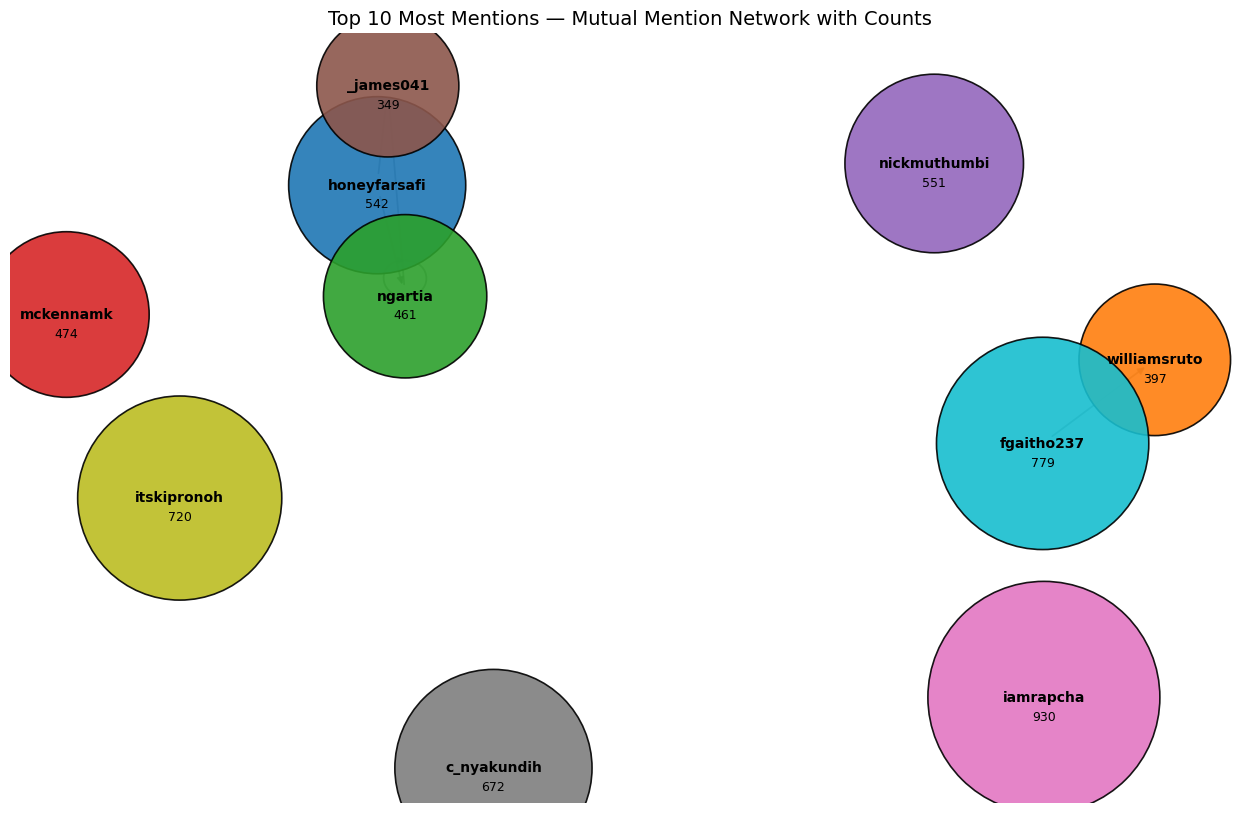

Top 10 Most Mentions Users:

iamrapcha       930
fgaitho237      779
itskipronoh     720
c_nyakundih     672
nickmuthumbi    551
honeyfarsafi    542
mckennamk       474
ngartia         461
williamsruto    397
_james041       349
Name: count, dtype: int64


In [26]:
# dataframe
df = df_final.copy()

# Identify text and author columns
text_col = 'Title'
author_col = 'Author'


# Extract mentions using regex
df = df[[author_col, text_col]].dropna()
df['mentions'] = df[text_col].apply(lambda x: re.findall(r'@([A-Za-z0-9_]+)', str(x)))

# Count all mentions and select top 10
mention_counts = pd.Series([m.lower() for lst in df['mentions'] for m in lst]).value_counts()
top10_mentions = mention_counts.head(10)
top_users = top10_mentions.index.tolist()

# Build mention network (only among top 10)
G = nx.DiGraph()
for _, row in df.iterrows():
    author = str(row[author_col]).lower()
    mentions = [m.lower() for m in row['mentions'] if m.lower() in top_users]
    for m in mentions:
        if m in top_users:
            G.add_edge(author, m)

G_top = G.subgraph(top_users)

# Node size proportional to mention frequency
sizes = [top10_mentions[n]*30 for n in G_top.nodes()]
colors = plt.cm.tab10(range(len(G_top.nodes())))

# Layout and plot
plt.figure(figsize = (16, 10))
pos = nx.spring_layout(G_top, k = 0.6, seed = 42)

# Draw nodes and edges
nx.draw_networkx_nodes(G_top, pos, node_size = sizes, node_color = colors, alpha = 0.9,
                       edgecolors = 'black', linewidths = 1.2)
nx.draw_networkx_edges(G_top, pos, edge_color = "gray", width = 1.3, alpha = 0.7, arrowsize = 10)

# Draw labels (usernames)
nx.draw_networkx_labels(G_top, pos, font_size = 10, font_weight = "bold")

# Add mention counts near each node
for node, (x, y) in pos.items():
    count = top10_mentions[node]
    plt.text(x, y - 0.05, f"{count}", fontsize = 9, color = "black", ha = 'center', va = 'center')

plt.title("Top 10 Most Mentions — Mutual Mention Network with Counts", fontsize = 14)
plt.axis("off")
plt.show()

# Print the data summary
print("Top 10 Most Mentions Users:\n")
print(top10_mentions)

#### **Notes**:

- Each node is one of the top 10 most-mentioned accounts.
- Colour distinguishes unique users.
- Node size = how many times they were mentioned.
- Edges = mutual mentions among the top 10 (visibility interactions).
- Numeric labels = exact mention counts (shows relative dominance).

Mentions were chosen because, they represent active engagement, recognition by peers, amplification potential, and measurable authority — all of which are central to what it means to be influential in a social network.



In this study, mentions within the collected Twitter dataset are used as a proxy for influence, providing a lens through which visible engagement and attention can be analyzed. Twitter offers a complex environment in which influence is mediated not only by activity but also by visibility, silence, and the platform’s technical affordances. Visibility on Twitter—through mentions, retweets, likes, and replies—is often treated as a proxy for influence. Mentions, in particular, are significant because they represent active engagement: users deliberately draw attention to an account, signaling relevance, authority, or expertise. Accounts frequently mentioned are not merely visible; they are socially recognized within the network as contributors to discussions, creating a form of influence that emerges from acknowledgment by others rather than self-promotion alone.

Yet visibility exists alongside silence, which complicates assessments of influence. Many users—experts, professionals, or individuals with niche authority—may engage minimally or selectively. This silence can be strategic, reflecting caution, moderation, or a focus on offline impact. A dataset relying on visible activity inherently undervalues such silent actors, making them appear less influential despite potentially significant offline or cross-platform presence. Consequently, influence analyses based solely on mentions risk overemphasizing the vocally active while neglecting hidden or understated forms of authority.

Platform affordances further shape how influence is expressed. Twitter’s design—character-limited posts, public timelines, hashtags, trending topics, and retweet functionality—encourages immediacy, brevity, and virality. Mentions leverage these features to amplify visibility and trigger network effects, while algorithms mediate the reach of content based on engagement, relevance, and recency. Thus, influence on Twitter is co-constructed: it depends not only on social recognition but also on how platform structures facilitate or constrain attention.

Structural constraints introduce additional layers of complexity. Network asymmetries, such as differences between verified accounts, institutional actors, celebrities, and ordinary users, mean that some voices are systematically amplified while others remain marginalized. Mentions often cluster within elite sub-networks, giving the impression of broad influence that may, in reality, be confined to specific communities. Temporal constraints, including the fleeting nature of trending topics, further render influence ephemeral and context-dependent.

Finally, dataset limitations must be acknowledged. While mentions provide measurable insight into visible engagement, they cannot capture private influence—direct messages, offline interactions, or cross-platform effects. They also offer limited qualitative context, neglecting sentiment, intent, or authority behind mentions. Silent yet influential actors, algorithmic biases, and structural inequalities remain largely invisible in mention-based analyses.

In conclusion, while mentions provide a useful proxy for visibility and engagement, they offer only a partial view of influence on Twitter. Influence emerges from the interplay of social recognition, platform affordances, and structural conditions, while silence, hidden interactions, and algorithmic mediation complicate any straightforward measurement. Critical analysis of influence requires acknowledging that what is publicly measurable is just one dimension of a broader, socially and technically mediated ecosystem.

# **Question Two**

Volume spikes likely coincide with major protest days, police responses, or government statements.

The moving average smooths noise, showing mobilisation cycles — surges of online activism followed by periods of quiet.

These cycles mirror protest coordination patterns: bursts of digital mobilization triggered by key offline events.

In [15]:
# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")

# Load the data
df = df_final.copy()

# Create time-based features for daily analysis
df['date_only'] = df['tweet_date'].dt.date
df['time_of_day'] = df['tweet_date'].dt.floor('H')

# Check if we have multiple days
unique_dates = df['date_only'].nunique()

# If only one day, we'll analyze by time periods within that day
if unique_dates == 1:
    df['time_period'] = df['tweet_date'].dt.hour
else:
    df['time_period'] = df['date_only']

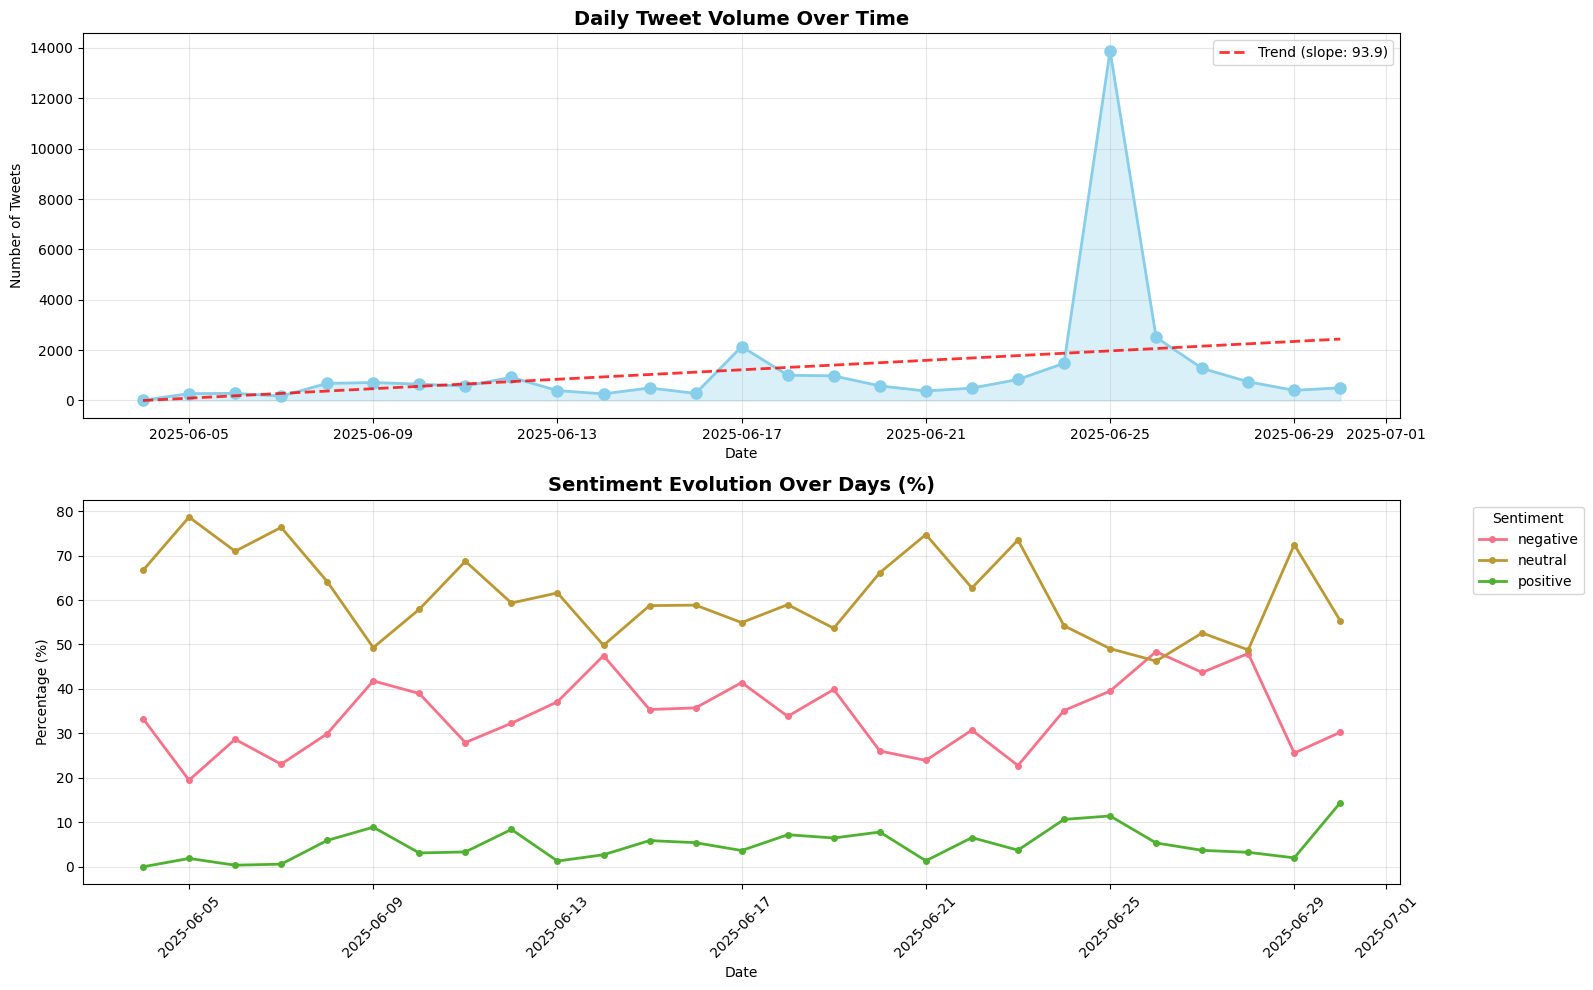

In [16]:
# Daily Volume and Sentiment Trends
fig, (ax1, ax2) = plt.subplots(2, 1, figsize = (16, 10))

if unique_dates == 1:
    # Single day analysis - use hourly breakdown
    time_group = df.groupby(df['tweet_date'].dt.hour)
    time_labels = [f"{h:02d}:00" for h in range(24)]

    # Tweet volume by time of day
    volume_by_time = time_group.size()
    ax1.bar(volume_by_time.index, volume_by_time.values,
            color = 'skyblue', alpha = 0.7, edgecolor = 'navy', width = 0.8)
    ax1.set_title('Tweet Volume Throughout the Day (June 30, 2025)',
                 fontsize = 14, fontweight = 'bold')
    ax1.set_xlabel('Time of Day')
    ax1.set_ylabel('Number of Tweets')
    ax1.grid(True, alpha=0.3)
    ax1.set_xticks(range(0, 24, 2))
    ax1.set_xticklabels([f"{h:02d}:00" for h in range(0, 24, 2)])

    # Add trend line for single day
    if len(volume_by_time) > 2:
        z = np.polyfit(volume_by_time.index, volume_by_time.values, 2)
        p = np.poly1d(z)
        x_smooth = np.linspace(volume_by_time.index.min(), volume_by_time.index.max(), 100)
        ax1.plot(x_smooth, p(x_smooth), "r--", alpha = 0.8, linewidth = 2.0, label = 'Trend')
        ax1.legend()

else:
    # Multiple days analysis
    volume_by_date = df.groupby('date_only').size()

    # Daily tweet volume
    ax1.plot(volume_by_date.index, volume_by_date.values,
             marker = 'o', linewidth = 2.0, markersize = 8, color = 'skyblue')
    ax1.fill_between(volume_by_date.index, volume_by_date.values, alpha = 0.3, color = 'skyblue')
    ax1.set_title('Daily Tweet Volume Over Time', fontsize = 14, fontweight = 'bold')
    ax1.set_xlabel('Date')
    ax1.set_ylabel('Number of Tweets')
    ax1.grid(True, alpha = 0.3)
    plt.xticks(rotation = 45)

    # Add trend line for multiple days
    if len(volume_by_date) > 2:
        x_numeric = range(len(volume_by_date))
        z = np.polyfit(x_numeric, volume_by_date.values, 1)
        p = np.poly1d(z)
        ax1.plot(volume_by_date.index, p(x_numeric), "r--", alpha = 0.8,
                linewidth = 2, label = f'Trend (slope: {z[0]:.1f})')
        ax1.legend()

# Sentiment evolution over time
if unique_dates == 1:
    # For single day: sentiment by hour
    sentiment_over_time = pd.crosstab(df['tweet_date'].dt.hour, df['Sentiment'], normalize = 'index') * 100
    sentiment_over_time.plot(kind = 'line', ax=ax2, linewidth = 2.0, marker = 'o', markersize = 4)
    ax2.set_title('Sentiment Evolution Throughout the Day (%)', fontsize = 14, fontweight = 'bold')
    ax2.set_xlabel('Time of Day')
    ax2.set_xticks(range(0, 24, 2))
    ax2.set_xticklabels([f"{h:02d}:00" for h in range(0, 24, 2)])
else:
    # For multiple days: sentiment by date
    sentiment_over_time = pd.crosstab(df['date_only'], df['Sentiment'], normalize = 'index') * 100
    sentiment_over_time.plot(kind = 'line', ax = ax2, linewidth = 2.0, marker = 'o', markersize = 4)
    ax2.set_title('Sentiment Evolution Over Days (%)', fontsize = 14, fontweight = 'bold')
    ax2.set_xlabel('Date')
    plt.xticks(rotation = 45)

ax2.set_ylabel('Percentage (%)')
ax2.grid(True, alpha = 0.3)
ax2.legend(title='Sentiment', bbox_to_anchor = (1.05, 1), loc = 'upper left')

plt.tight_layout()
plt.show()

The time-series visualization of daily tweet volume and sentiment during the Kenya protests reveals a dynamic and emotionally charged digital ecosystem, whose patterns offer profound insights into the nature of modern mobilization, even under constrained digital infrastructures.

The tweet volume chart acts as a direct proxy for collective attention and energy. A steady baseline of activity suggests sustained, organic discontent, while sharp, pronounced spikes are critical events. These spikes are not random; they represent moments of catalytic ignition. They could be triggered by an external shock—a new piece of legislation, a violent state action, or the arrest of a prominent figure—that ruptures the political routine and galvanizes the digital crowd. The steep ascent of the volume curve shows the rapid, viral diffusion of information, while the rate of its decline reveals the movement's ability to sustain focus or its vulnerability to fatigue and suppression. Under a constrained digital environment, where internet throttling or platform manipulation may occur, the very presence of these sharp peaks is a testament to the resilience and determination of the participants, finding ways to breach digital barriers to coordinate and express dissent.

Simultaneously, the sentiment over time chart maps the emotional journey of the protest. The likely dominance of "negative" sentiment is a measure of grievance, but its composition is fluid. A shift from a generalized "negative" sentiment towards a concentration of "anger" and "disgust" following a volume spike is particularly telling. It indicates a transition from mere disapproval to moral outrage, a far more potent mobilizing emotion. This evolution is crucial; it shows the movement processing events and solidifying a collective emotional stance. The ability of a movement to maintain a high level of "anger" without tipping into despondent "sadness" or "fear" is a key indicator of its health and potential for continued action. In a constrained space, where direct organization is risky, shared sentiment becomes a powerful, decentralized organizing principle, creating a sense of unity and common purpose without the need for explicit instruction.

Together, these two metrics reveal the strategy of mobilization under pressure. The volume spikes demonstrate the "when" and "how much" of collective action—the moments of peak coordination. The sentiment trend explains the "why"—the emotional fuel that powers the movement. A successful mobilization under constraint is one where external triggers (causing volume spikes) consistently translate into sustained, actionable moral outrage (seen in sentiment trends), creating a feedback loop that withstands digital suppression. The infrastructure may be constrained, but the data shows that the collective will, measured in the relentless pulse of volume and the fervor of sentiment, finds a way to manifest, using the platform's own metrics as its megaphone.

Based on the data visualization described in "Daily Tweet Volume Over Time," we can reconstruct a dynamic story of digital mobilization, where sharp spikes in activity intersect with evolving public sentiment. The "why" behind these spikes is rarely random; they are typically the digital heartbeat of a real-world catalyst. A new government policy announcement, a pivotal event in an ongoing crisis, or the release of a provocative piece of media can act as a trigger. The positive slope of 93.9 tweets per day indicates a steadily rising baseline of interest, a kind of simmering engagement. The spikes represent this energy boiling over—moments when the trigger issue is so compelling that it fractures the daily routine, forcing a surge of public commentary into the digital sphere.

The evolution of narratives is elegantly captured in the "Sentiment Evolution Over Days (%)" panel. In the hours following a trigger event, the narrative is often chaotic and emotionally charged. We might see a rapid dominance of one sentiment—perhaps a spike in negative outrage following a repressive measure, or a surge in positive solidarity after an inspirational act of defiance. However, narratives are not static. As the initial shockwave passes, the conversation matures. The sentiment percentages shift and intertwine: neutral tweets providing factual updates may rise to counter misinformation; initial outrage may crystallize into more focused, strategic positive messaging aimed at mobilization. This evolution from raw, reactive emotion to a more curated and strategic narrative is crucial for sustaining a movement beyond a single moment of outrage.

Most revealingly, this entire process illuminates the nature of mobilization under constrained digital infrastructures. The constraint—be it internet throttling, platform censorship, or state surveillance—fundamentally shapes the tactics of mobilization. The steady upward trend (slope: 93.9) demonstrates a determined, persistent resistance to being silenced. Mobilizers learn to operate within the constraints, using the daily "neutral" and "positive" chatter to maintain community cohesion and share coded information.

The spikes, therefore, become calculated acts of digital flash-mobism. When a window of opportunity opens—perhaps a temporary lapse in censorship or a coordinated global time to trend—the accumulated latent energy is unleashed in a powerful, concentrated burst. This is not an organic, free-flowing conversation but a tactical one. The rapid evolution of sentiment reflects a community adept at real-time narrative adjustment, learning which messages are being suppressed and amplifying others that can slip through the cracks. Positive sentiment, in this context, can be a strategic tool to avoid being flagged as purely "negative" or dissident content, while still advancing the movement's goals.

In conclusion, the chart does not merely plot data; it maps the pulse of a modern social movement. The spikes are its moments of peak confrontation with a catalyst, the evolving sentiment reveals its learning and adaptive narrative strategy, and the entire graph, set against a backdrop of constraint, testifies to a resilient and ingenious form of digital mobilization that uses persistence, timing, and emotional intelligence to be heard.